In [2]:
import requests
import pandas as pd
import folium
import numpy as np
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def fetch_and_prepare_data(n_skus=950):
    url="https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    df=pd.read_excel(url)
    
    df=df[df["Quantity"] > 0]

    # Get the top SKUs
    top_skus=df.groupby("StockCode")["Quantity"].sum().nlargest(n_skus).index
    df=df[df["StockCode"].isin(top_skus)].copy()

    df["Date"]=pd.to_datetime(df["InvoiceDate"]).dt.date
    df=df.rename(columns={"Country": "Region"})

    daily_sales=df.groupby(["Date", "Region", "StockCode"])["Quantity"].sum().reset_index()
    daily_sales=daily_sales.rename(columns={"Quantity": "Units_Sold"})

    simulated_data=[]
    for (region, stockcode), group in daily_sales.groupby(["Region", "StockCode"]):
        group=group.sort_values("Date")

        current_stock=500
        stock_history =[]
        reorder_history= []

        for sales in group["Units_Sold"]:
            current_stock -= sales
            
            if current_stock <=100:
                reorder_history.append(1)
                current_stock = 500
            else:
                reorder_history.append(0)

            stock_history.append(current_stock)

        group["Current_Stock"]= stock_history
        group["Reorder_Triggered"] = reorder_history

        simulated_data.append(group)

    final_df = pd.concat(simulated_data, ignore_index=True)
    final_df["Date"]=pd.to_datetime(final_df["Date"])
    print(f"Successfully generated {len(final_df)} rows of fully prepped warehouse data!")
    return final_df


data= fetch_and_prepare_data(950)

Successfully generated 170638 rows of fully prepped warehouse data!


In [4]:


def fetch_nairobi_retail_nodes():
    """ Querying OpenStreetMap for Nairobi retail nodes..."""
    
    overpass_url= "http://overpass-api.de/api/interpreter"
    overpass_query="""
    [out:json][timeout:25];
    (
        node["amenity"="bar"](-1.44,36.65,-1.15,37.10);
        node["amenity"="pub"](-1.44,36.65,-1.15,37.10);
        node["shop"="supermarket"](-1.44,36.65,-1.15,37.10);
        node["shop"="convenience"](-1.44,36.65,-1.15,37.10);
    );
    out center;    
    """

    headers={
        "User-Agent": "Adiel_Nairobi_RTM_Research_Project/1.0"
    }

    response=requests.post(overpass_url,data={'data': overpass_query}, headers=headers)

    if response.status_code == 200:
        data =  response.json()
        nodes=[]
        for element in data["elements"]:

            tags=element.get("tags",{})
            name= tags.get('name', 'Unnamed Store')

            if tags.get("amenity") in ["bar", "pub"]:
                node_type= 'Bar/Pub'
            elif tags.get("shop")=="supermarket":
                node_type="Supermarket"
            elif tags.get("shop")=="convenience":
                node_type= "Convenience/Duka"
            else:
                node_type="Other"
            
            nodes.append({
                "Node_ID": element["id"],
                'Name':name,
                "Type": node_type,
                "Latitude": element["lat"],
                "Longitude": element["lon"]
            })

        df_nodes = pd.DataFrame(nodes)
        print(f"Successfully extracted {len(df_nodes)} delivery nodes in Nairobi!")
        return df_nodes
    else:
        print(f"Error: Failed to fetch data. Status code: {response.status_code}")
        return None
if __name__ == "__main__":
    nairobi_df=fetch_nairobi_retail_nodes()

    if nairobi_df is not None:
        print(nairobi_df["Type"].value_counts())
        print("\nFirst 5 Rows:")
        print(nairobi_df.head())

        nairobi_df.to_csv("Nairobi_delivery_nodes.csv", index=False)
        print("\n Saved as Nairobi CSV")
        

Successfully extracted 1026 delivery nodes in Nairobi!
Type
Bar/Pub             631
Supermarket         284
Convenience/Duka    111
Name: count, dtype: int64

First 5 Rows:
    Node_ID           Name         Type  Latitude  Longitude
0  30092040      Carrefour  Supermarket -1.298407  36.763324
1  30210335         Barizi      Bar/Pub -1.292564  36.786825
2  30324274     Soho's Bar      Bar/Pub -1.262588  36.805176
3  30324343      Carrefour  Supermarket -1.260903  36.801831
4  30402750  K1 Klub House      Bar/Pub -1.268460  36.811872

 Saved as Nairobi CSV


In [5]:
df= pd.read_csv("Nairobi_delivery_nodes.csv")

nairobi_map = folium.Map(location=[-1.2921, 36.8219], zoom_start=12, tiles="CartoDB positron")

for idx, row in df.head(200).iterrows():
    if row["Type"] == "Supermarket":
        color = "green"
    elif row["Type"] == "Bar/Pub":
        color="red"
    else:
        color="blue"
    
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        popup=row["Name"],
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(nairobi_map)

nairobi_map.save("nairobi_delivery_map.html")

In [6]:
def generate_cbk_macro_features():
    dates = pd.date_range(start="2012-01-01", end="2025-12-31", freq="D")
    periods= len(dates)

    trend= np.linspace(5,250,periods)

    seasonality=np.sin(np.linspace(0,3.14*168, periods))*12

    payday_effect=dates.is_month_end.astype(int)*35

    noise=np.random.normal(0,4,periods)

    mobile_money_vol= trend+seasonality+payday_effect+noise

    df_macro=pd.DataFrame({
        "Date":dates,
        "Mobile_Money_Volume_Billion_KES": np.round(np.maximum(mobile_money_vol,0),2),
        "End_of_Month_Flag": dates.is_month_end.astype(int)
    })
    return df_macro

if __name__ =="__main__":
    macro_df=generate_cbk_macro_features()
    print("\n --- First 5 Rows ---")
    print(macro_df.head())
    print("\n --- Last 5 Rows ---")
    print(macro_df.tail())

    macro_df.to_csv("CBK_Mobile_Money_2012_2025.csv",index=False)

    print(f"\n Saved {len(macro_df)} days of macroeconomic data to the csv")



 --- First 5 Rows ---
        Date  Mobile_Money_Volume_Billion_KES  End_of_Month_Flag
0 2012-01-01                             1.95                  0
1 2012-01-02                             1.63                  0
2 2012-01-03                             3.06                  0
3 2012-01-04                             4.53                  0
4 2012-01-05                             9.76                  0

 --- Last 5 Rows ---
           Date  Mobile_Money_Volume_Billion_KES  End_of_Month_Flag
5109 2025-12-27                           240.81                  0
5110 2025-12-28                           244.97                  0
5111 2025-12-29                           246.21                  0
5112 2025-12-30                           243.06                  0
5113 2025-12-31                           281.12                  1

 Saved 5114 days of macroeconomic data to the csv



### EDA

In [7]:
df_fmcg_eda=data.copy()
df_fmcg_eda["Date"]= pd.to_datetime(df_fmcg_eda["Date"]).dt.normalize()
df_fmcg_eda["Date"] = df_fmcg_eda["Date"] + pd.DateOffset(years=14)

In [8]:
df_macro_eda = pd.read_csv("CBK_Mobile_Money_2012_2025.csv")
df_macro_eda["Date"]=pd.to_datetime(df_macro_eda["Date"])

In [9]:
eda_df= pd.merge(df_fmcg_eda,df_macro_eda, on="Date", how="inner")

eda_df["Target_Reorder_Next_3_Days"]= eda_df.groupby(["Region", "StockCode"])["Reorder_Triggered"].transform(
    lambda x: x.shift(-1).rolling(window=3, min_periods=1).max()
)
eda_df = eda_df.dropna().reset_index(drop=True)

In [10]:
# Class Imbalance Check
class_counts= eda_df["Target_Reorder_Next_3_Days"].value_counts(normalize=True) * 100
print(f"No Reororder (0): {class_counts[0]:.2f}%\nReorder Triggered (1): {class_counts[1]:.2f}%")


No Reororder (0): 86.41%
Reorder Triggered (1): 13.59%


In [11]:
# Macroeconomic Impact Analysis
avg_liquidity=eda_df.groupby("Target_Reorder_Next_3_Days")["Mobile_Money_Volume_Billion_KES"].mean()
print(f"Average Daily Liquidity on normal days: KES {avg_liquidity[0]:.2f} Billion")
print(f"Average Daily Liquidity when a Reorder triggers: KES {avg_liquidity[1]:.2f} Billion")


Average Daily Liquidity on normal days: KES 243.32 Billion
Average Daily Liquidity when a Reorder triggers: KES 244.73 Billion


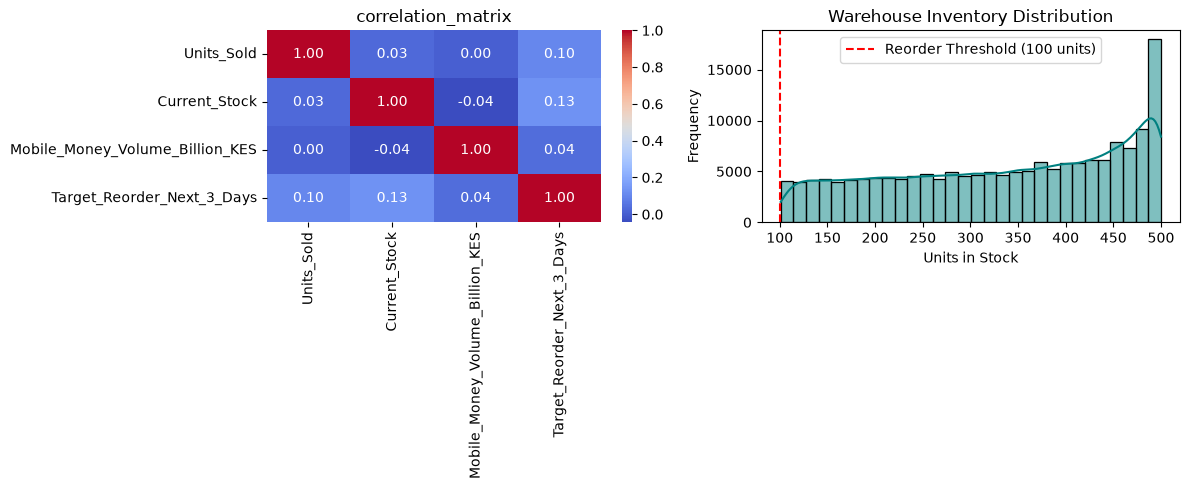

In [12]:
# Correlation Check
features_for_corr=["Units_Sold", "Current_Stock", "Mobile_Money_Volume_Billion_KES","Target_Reorder_Next_3_Days"]
correlation_matrix =eda_df[features_for_corr].corr()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(correlation_matrix,annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation_matrix")

plt.subplot(1,2,2)
sns.histplot(eda_df["Current_Stock"],bins=30,kde=True,color="teal")
plt.axvline(100,color="red", linestyle="--", label="Reorder Threshold (100 units)")
plt.title("Warehouse Inventory Distribution")
plt.xlabel("Units in Stock")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
def train_macro_fmcg_model(model,fmcg_data):

    df_fmcg = fmcg_data.copy()
    df_fmcg["Date"] = pd.to_datetime(df_fmcg["Date"].dt.normalize())

    df_fmcg["Date"] = df_fmcg["Date"] + pd.DateOffset(years=14)

    df_macro=pd.read_csv("CBK_Mobile_Money_2012_2025.csv")
    df_macro["Date"]= pd.to_datetime(df_macro["Date"])

    df= pd.merge(df_fmcg,df_macro,on="Date", how="inner")

    print(f"Merged successfully. Modeling {len(df)} days of macroeconomic-backed supply chain data.")

    df["Sales_Lag_1"]=df.groupby(["Region","StockCode"])["Units_Sold"].shift(1)
    df["Sales_Lag_2"]=df.groupby(["Region", "StockCode"])["Units_Sold"].shift(2)
    df["Sales_Rolling_Mean_3"]= df.groupby(["Region", "StockCode"])["Units_Sold"].transform(lambda x: x.shift(1).rolling(window=3).mean())
    df["Sales_Rolling_Mean_7"]= df.groupby(["Region", "StockCode"])["Units_Sold"].transform(lambda x: x.shift(1).rolling(window=7).mean())
    df["Stock_Lag_1"]= df.groupby(["Region","StockCode"])["Current_Stock"].shift(1)
    df["Day_of_Week"]= df["Date"].dt.dayofweek


    df["Target_Reorder_Next_3_days"]=df.groupby(["Region", "StockCode"])["Reorder_Triggered"].transform(
        lambda x: x.shift(-1).rolling(window=3, min_periods=1).max()
    )

    df=df.dropna().reset_index(drop=True)

    feature_cols=[
        "Sales_Lag_1",
        "Sales_Lag_2",
        "Sales_Rolling_Mean_3",
        "Sales_Rolling_Mean_7",
        "Stock_Lag_1",
        "Day_of_Week",
        "Mobile_Money_Volume_Billion_KES",
        "End_of_Month_Flag"
    ]
    X=df[feature_cols]
    y= df["Target_Reorder_Next_3_days"]

    df= df.sort_values("Date")
    split_idx=int(len(df) * 0.8)
    X_train,X_test=X.iloc[:split_idx],X.iloc[split_idx:]
    y_train,y_test=y.iloc[:split_idx],y.iloc[split_idx:]

    print(f"Training set size: {len(X_train)} | Test Set size: {len(X_test)}")

    model.fit(X_train,y_train)
    y_pred= model.predict(X_test)

    print(f"\n--- MACRO BACKED 3-DAY FORECAST EVALUATION ---\n{classification_report(y_test,y_pred)}")
    print("\n --- Feature Importance ---")

    importance= model.feature_importances_
    for name, importance in zip(feature_cols, importance):
        print(f"{name}: {importance:.4f}")
    
    return model


In [14]:

rfc_macro= RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced")

trained_macro_model = train_macro_fmcg_model(model=rfc_macro,fmcg_data=data)

Merged successfully. Modeling 170638 days of macroeconomic-backed supply chain data.
Training set size: 113417 | Test Set size: 28355

--- MACRO BACKED 3-DAY FORECAST EVALUATION ---
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95     22992
         1.0       0.79      0.74      0.76      5363

    accuracy                           0.91     28355
   macro avg       0.87      0.85      0.86     28355
weighted avg       0.91      0.91      0.91     28355


 --- Feature Importance ---
Sales_Lag_1: 0.0871
Sales_Lag_2: 0.0568
Sales_Rolling_Mean_3: 0.1029
Sales_Rolling_Mean_7: 0.1074
Stock_Lag_1: 0.5527
Day_of_Week: 0.0243
Mobile_Money_Volume_Billion_KES: 0.0668
End_of_Month_Flag: 0.0019
